In [1]:
import numpy as np
# import pandas as pd

# csv_path = 'counts_from_ana/DES_bestfit_analyt_bias_counts_z0p275-3.csv'

# df = pd.read_csv(csv_path, sep=',')
# df.columns = df.columns.str.replace(' ', '')
# counts_cols = [c for c in df.columns if c.startswith('counts_')]
# bias_cols = [c for c in df.columns if c.startswith('bias_')]

# counts = df[counts_cols].to_numpy()
# bias = df[bias_cols].to_numpy()

# print(counts)
# print(bias)

In [14]:
### my code
from clens.util.parameters import CosmoParameters
from clens.util.scaling_relation import To25ScalingRelation
from clens.util.cluster_counts import ClusterCounts

cosmo_parameters = CosmoParameters(h=0.67, OmegaDE=0.706, OmegaM=0.294, sigma8=0.822, w0=-0.727, wa=-1.05, ns=0.96, OmegaB=0.022)

#scaling_relation = FiducialScalingRelation()
#scaling_relation = Costanzi21ScalingRelation()
scaling_relation = To25ScalingRelation(lnlam0=3.874, A_lnlam=0.903, B_lnlam=0.163, sig_lnlam=0.238, Mpivot=5e14/0.67)


am = 0.903
B_lam = 0.163
ln_lam0 = 3.874
sigma_int = 0.238

print(np.exp(scaling_relation.lnlambda_lnM(np.log(1e13/0.67), 0.275)))

print(scaling_relation.scatter(np.log(1e13/0.67), 0.275))

# cmm = ClusterCounts(cosmo_parameters=cosmo_parameters, scaling_relation=scaling_relation)

# cc = cmm.calc_counts(zmin=0.2, zmax=0.35, lambda_min=60, lambda_max=1000, survey_area_sq_deg=10000)
# print(cc[0])

1.3777870064929985
0.5056259901859196


In [3]:
# counts

In [ ]:
from clens.ying.halostat import HaloStat
from clens.ying.param_w0wa import CosmoParams

cp = cosmo_parameters
cosmo = CosmoParams(omega_M_0=cp.OmegaM, omega_b_0=cp.OmegaB, omega_lambda_0=cp.OmegaDE, h=cp.h, sigma_8=cp.sigma8, n=cp.ns, tau=cp.tau, w0=cp.w0, wa=cp.wa)

redshift = 0.275
#redshift = 0.425
#redshift = 0
DELTA_HALO = 200.0
from clens.ying.density_w0wa import Density
den = Density(cosmo=cosmo)
rho_mean_0 = den.rho_mean_z(0.)


M_arr = np.array([1e13/cp.h, 1e14/cp.h, 5e14/cp.h, 1e15/cp.h])
dlnM = 0.01
hs = HaloStat(cosmo=cosmo, z=redshift, DELTA_HALO=DELTA_HALO, rho_mean_0=rho_mean_0, mass=M_arr, dlogm=dlnM)
dndM_arr = hs.mass_function


print(dndM_arr * M_arr / 0.67**3)

mass_heidi = M_arr
mf_heidi = dndM_arr * M_arr / 0.67**3

[5.06228482e-04 4.55246886e-05 3.57748359e-06 6.60632582e-07]


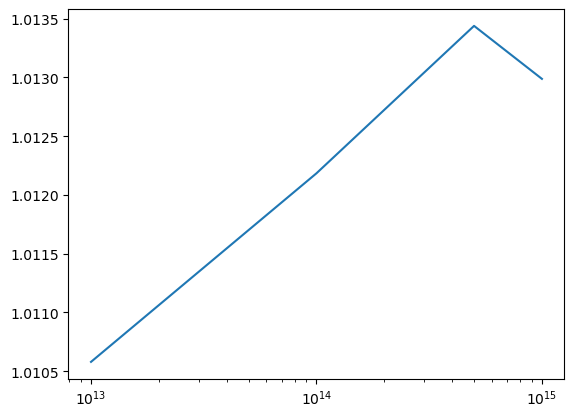

In [5]:
## Ana's code
from colossus.cosmology import cosmology
from colossus.lss import mass_function

# best-fit values from DES for Om, sigma8, and nuisance params
ns = 0.96
H_0 = 67
O_M = 0.294
O_B = 0.022
O_L = 1 - O_M
sigma8 = 0.822
w_0 = -0.727
w_a = -1.05
A_lam = 0.903
B_lam = 0.163
ln_lam0 = 3.874
sigma_int = 0.238



#getting the values for these parameters from the ith cosmology
params = {'flat': True, 'H0': H_0, 'Om0': O_M, 'Ode0': O_L, 'Ob0': O_B,'sigma8': sigma8, 'ns': ns, 'w0': w_0, 'wa': w_a, 'de_model': 'w0wa'}
cosmology.addCosmology('cosmos1', params) #adding a new cosmology
cosmo = cosmology.setCosmology('cosmos1') #setting the cosmology

mass_ana = [1e13, 1e14, 5e14, 1e15]
mf_ana = []
for M in mass_ana:
    #print(M, mass_function.massFunction(M, 0.275, mdef='200m', model='tinker08', q_out='dndlnM'))
    mf_ana.append(mass_function.massFunction(M, redshift, mdef='200m', model='tinker08', q_out='dndlnM'))

import matplotlib.pyplot as plt 
plt.plot(mass_ana, mf_ana/mf_heidi)
plt.xscale('log')
#plt.loglog(mass_heidi*cp.h, )